In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_csv("src/data/lenguaspaises.csv")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2810 entries, 0 to 2809
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    2810 non-null   int64  
 1   Name_English          2810 non-null   str    
 2   Countries             2810 non-null   str    
 3   Degree_endangerment   2810 non-null   str    
 4   Number_speakers       2810 non-null   float64
 5   Description_location  1998 non-null   str    
 6   endangerment_score    2810 non-null   int64  
 7   Countries_list        2810 non-null   str    
 8   Region                2801 non-null   str    
 9   Population            2801 non-null   float64
 10  Area_sq_mi            2801 non-null   float64
 11  Pop_density           2801 non-null   float64
 12  Coastline             2801 non-null   float64
 13  Migration             2801 non-null   float64
 14  Infant_mortality      2801 non-null   float64
 15  GDP                   2801 non-n

In [4]:
print(df.columns.tolist())

['ID', 'Name_English', 'Countries', 'Degree_endangerment', 'Number_speakers', 'Description_location', 'endangerment_score', 'Countries_list', 'Region', 'Population', 'Area_sq_mi', 'Pop_density', 'Coastline', 'Migration', 'Infant_mortality', 'GDP', 'Literacy', 'Phones', 'Arable', 'Crops', 'Other', 'Climate', 'Birthrate', 'Deathrate', 'Agriculture', 'Industry', 'Service']


### Análisis univariante: grado de peligro de extinción

mean      2.609253
median    2.000000
std       1.288136
min       1.000000
max       5.000000
Name: endangerment_score, dtype: float64


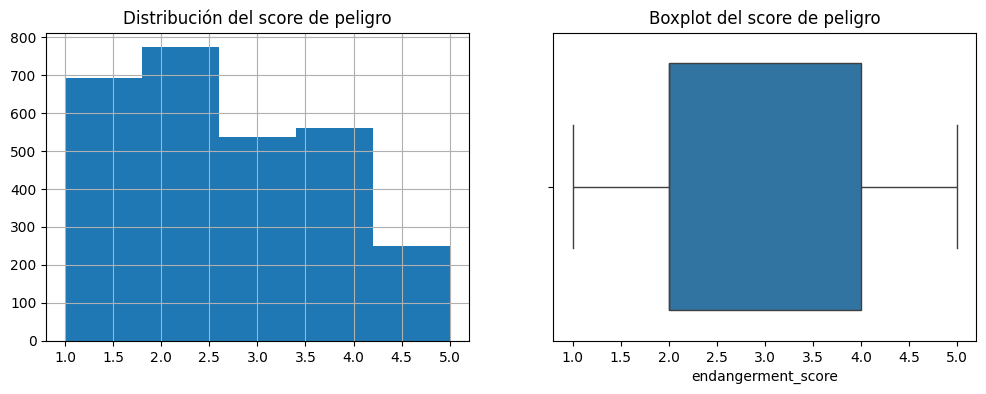

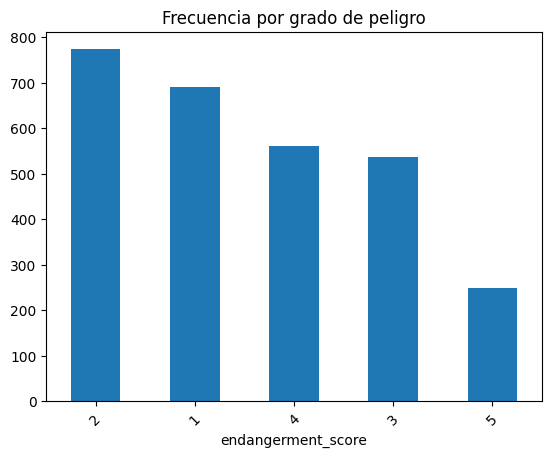

In [5]:
# Estadísticos de centralidad y dispersión
stats = df['endangerment_score'].agg(['mean', 'median', 'std', 'min', 'max'])
print(stats)

# Histograma + boxplot de endangerment_score
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['endangerment_score'].hist(bins=5, ax=axes[0])
axes[0].set_title('Distribución del score de peligro')
sns.boxplot(x=df['endangerment_score'], ax=axes[1])
axes[1].set_title('Boxplot del score de peligro')
plt.show()

# Variable categórica: grado de peligro
df['endangerment_score'].value_counts().plot(kind='bar')
plt.title('Frecuencia por grado de peligro')
plt.xticks(rotation=45)

plt.savefig("src/img/Univariante.png",
            dpi=300,
            bbox_inches="tight")  

plt.show()

# H1 - Grado de peligro y región

Hipótesis: **La distribución del grado de peligro lingüístico varía significativamente según la región del mundo: hay más lenguas críticamente en peligro en Asia-Pacífico y América que en Europa.** 
 
Para analizar la relación entre la región geográfica y el grado de peligro de las lenguas, se ha construido una tabla de contingencia normalizada por filas, permitiendo comparar la distribución relativa de cada categoría de peligro dentro de cada región. Esta normalización facilita la identificación de patrones entre regiones independientemente del número total de lenguas registradas en cada una de ellas. Los resultados obtenidos se representan mediante un heatmap, permitiendo visualizar de forma más clara las diferencias de distribución entre regiones.

Además, se llevará a cabo el Test Chi-Cuadrado de independencia con el objetivo de determinar si existe una relación estadísticamente significativa entre ambas variables, es decir, si la distribución de los grados de peligro depende de la región considerada.

#### Tabla de contingencia normalizada:

In [4]:
tabla_contingencia = pd.crosstab(df["Region"],
                                 df["endangerment_score"])


tabla_contingencia.columns = [
    "Vulnerable",
    "Definitely endangered",
    "Severely endangered",
    "Critically endangered",
    "Extinct"
]

tabla_norm = tabla_contingencia.div(
    tabla_contingencia.sum(axis=1),
    axis=0
)

tabla_norm

,Vulnerable,Definitely endangered,Severely endangered,Critically endangered,Extinct
Region,,,,,
ASIA (EX. NEAR EAST),0.297365,0.365119,0.126725,0.160602,0.050188
BALTICS,0.333333,0.444444,0.111111,0.000000,0.111111
C.W. OF IND. STATES,0.167568,0.378378,0.194595,0.113514,0.145946
EASTERN EUROPE,0.301887,0.415094,0.226415,0.000000,0.056604
LATIN AMER. & CARIB,0.344828,0.217868,0.180251,0.199060,0.057994
NEAR EAST,0.150943,0.358491,0.283019,0.075472,0.132075
NORTHERN AFRICA,0.185185,0.111111,0.259259,0.296296,0.148148
NORTHERN AMERICA,0.134948,0.148789,0.211073,0.325260,0.179931
OCEANIA,0.204403,0.169811,0.264151,0.286164,0.075472


## H1 - Visualizaciones

#### Heatmap - Distribución del grado de peligro por región:

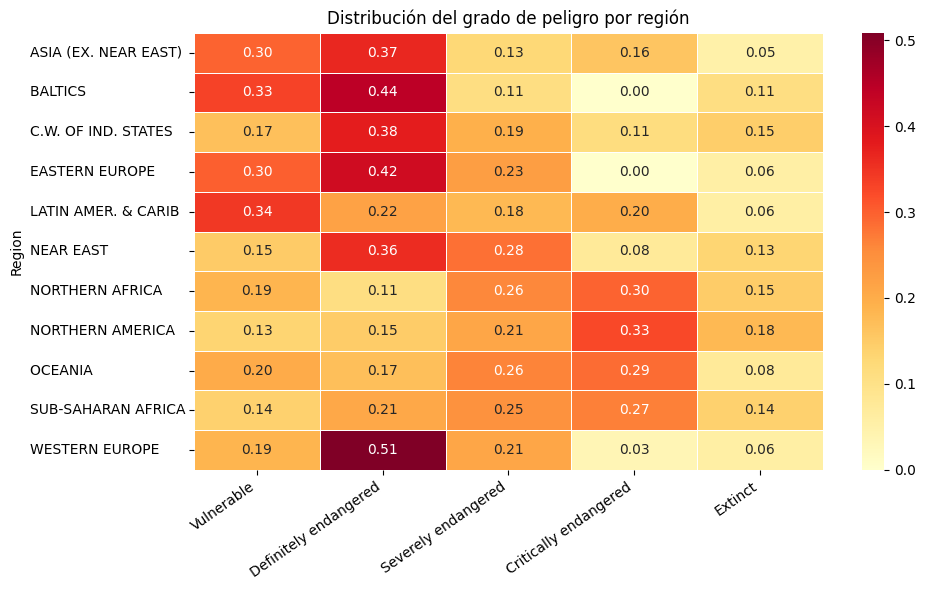

In [5]:
plt.figure(figsize=(10,6))

ax = sns.heatmap(
    tabla_norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=.5
)

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    ha="left"
)

ax.tick_params(axis='y', pad=115)

plt.xticks(rotation=35, ha="right")

plt.title("Distribución del grado de peligro por región")


plt.tight_layout()
plt.savefig("src/img/H1-heatmap.png",
            dpi=300,
            bbox_inches="tight")  
plt.show()

#### Test Chi-Cuadrado (Chi2 Contingency). Región - Grado de peligro:

In [8]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(tabla_contingencia)


print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 373.0334204206096
P-Value: 1.2639620242153418e-55
Grados de Libertad: 40
Tabla de Frecuencias Esperadas:
 [[196.33345234 219.09675116 151.94501964 159.62763299  69.99714388]
 [  2.21706533   2.47411639   1.71581578   1.80257051   0.79043199]
 [ 45.57300964  50.85683684  35.26954659  37.05283827  16.24776865]
 [ 13.05605141  14.5697965   10.10424848  10.61513745   4.65476615]
 [157.16529811 175.38736166 121.63227419 127.78222064  56.03284541]
 [ 13.05605141  14.5697965   10.10424848  10.61513745   4.65476615]
 [  6.651196     7.42234916   5.14744734   5.40771153   2.37129597]
 [ 71.19243127  79.4466262   55.09675116  57.88254195  25.38164941]
 [ 78.33630846  87.41877901  60.6254909   63.69082471  27.92859693]
 [ 77.35094609  86.31917172  59.8629061   62.88968226  27.57729382]
 [ 29.06818993  32.43841485  22.49625134  23.63370225  10.36344163]]


In [9]:
tabla_contingencia

,Vulnerable,Definitely endangered,Severely endangered,Critically endangered,Extinct
Region,,,,,
ASIA (EX. NEAR EAST),237,291,101,128,40
BALTICS,3,4,1,0,1
C.W. OF IND. STATES,31,70,36,21,27
EASTERN EUROPE,16,22,12,0,3
LATIN AMER. & CARIB,220,139,115,127,37
NEAR EAST,8,19,15,4,7
NORTHERN AFRICA,5,3,7,8,4
NORTHERN AMERICA,39,43,61,94,52
OCEANIA,65,54,84,91,24


## H1 -Resultados e interpretación

##### Heatmap - Distribución del grado de peligro por región:

El heatmap permite observar diferencias claras en la distribución del grado de peligro de las lenguas según la región analizada. En regiones como Asia (excepto Oriente Próximo), Bálticos, Comunidad de Estados Independientes, Europa del Este, Latinoamérica y Caribe, Europa Occidental y Oriente Próximo, la mayor proporción de lenguas se concentra en categorías de peligro inferiores, especialmente en los niveles “Vulnerable” y “Definitely endangered”. Además, en estas regiones los porcentajes asociados a las categorías más cercanas a la extinción son relativamente reducidos.

Por el contrario, en regiones como Norteamérica, Norte de África, África Subsahariana y Oceanía se observa una mayor concentración de lenguas en categorías de peligro más elevadas. En estas regiones, la categoría “Critically endangered” presenta los porcentajes más altos dentro de cada distribución regional, lo que sugiere una situación de mayor riesgo para las lenguas minoritarias.

Estos resultados podrían estar relacionados con procesos de homogeneización lingüística, donde las lenguas dominantes o mayoritarias adquieren un peso cada vez mayor frente a lenguas locales o secundarias, favoreciendo así la pérdida progresiva de estas últimas y aumentando su cercanía a la extinción.

##### Test Chi-Cuadrado (Chi2 Contingency). Región - Grado de peligro:

Los resultados obtenidos en el Test Chi-Cuadrado permiten rechazar claramente la hipótesis nula de independencia, dado que el p-valor obtenido es extremadamente reducido y próximo a 0. Esto indica que existe una relación estadísticamente significativa entre la región geográfica y el grado de peligro de extinción de las lenguas registradas en dichas regiones.

Además, el elevado valor del estadístico Chi-Cuadrado refleja que las diferencias entre las frecuencias observadas y las frecuencias esperadas bajo el supuesto de independencia son considerables. Esto sugiere que la distribución del grado de peligro no se produce de manera homogénea entre regiones, sino que determinadas regiones presentan patrones claramente diferenciados.

Los resultados observados en el heatmap respaldan esta conclusión, ya que regiones como Norteamérica, Oceanía o África Subsahariana presentan una mayor concentración de lenguas en categorías críticas de peligro, mientras que otras regiones concentran una mayor proporción de lenguas en categorías de riesgo más moderado.

Aunque el test confirma la existencia de relación entre ambas variables, no permite establecer causalidad directa, sino únicamente asociación estadística entre la región y el nivel de peligro de extinción de las lenguas.

## H1 - Conclusiones

En conjunto, los resultados obtenidos permiten concluir que existe una relación estadísticamente significativa entre la región geográfica y el grado de peligro de extinción de las lenguas. Tanto el heatmap normalizado como el Test Chi-Cuadrado muestran que la distribución de las categorías de peligro no es homogénea entre regiones, observándose patrones claramente diferenciados.

Mientras que regiones como Asia (excepto Oriente Próximo), los Bálticos, la Comunidad de Estados Independientes, Europa del Este, Latinoamérica y Caribe, Oriente Próximo o Europa Occidental concentran una mayor proporción de lenguas en categorías de riesgo moderado, regiones como Norteamérica, Oceanía, Norte de África o África Subsahariana presentan una mayor presencia de lenguas en situación crítica. Estos resultados sugieren que factores regionales, sociales y lingüísticos pueden influir notablemente en la conservación o desaparición progresiva de las lenguas minoritarias, favoreciendo en determinados contextos procesos de homogeneización lingüística y pérdida de diversidad cultural.

De esta manera, la hipótesis planteada queda **parcialmente confirmada**. Aunque se esperaba encontrar una mayor concentración de lenguas críticamente en peligro en Asia-Pacífico y América respecto a Europa, los resultados muestran una distribución del riesgo lingüístico más heterogénea de lo inicialmente previsto. Si bien algunas regiones de América y Oceanía presentan una elevada proporción de lenguas en estados críticos, otras zonas asiáticas y europeas concentran principalmente niveles de peligro moderado. Por tanto, puede afirmarse que el grado de peligro lingüístico varía significativamente según la región del mundo, aunque los patrones observados no coinciden completamente con lo planteado en la hipótesis inicial.

# H2: Variabilidad por región

Hipótesis: **La variabilidad en el número de hablantes de lenguas en peligro es mucho mayor en Asia que en Europa: hay lenguas con miles de hablantes y otras casi extintas en la misma región**

El objetivo de este análisis es estudiar la variabilidad en el número de hablantes de las lenguas en peligro según la región geográfica. Para ello, se utilizará un boxplot en escala logarítmica acompañado de un stripplot, permitiendo visualizar tanto la distribución general como la dispersión individual de los datos. Además, se calculará el rango intercuartílico (IQR) de cada región con el fin de comparar especialmente la variabilidad existente entre Asia y Europa.

Para analizar esta hipótesis, y debido al uso de una escala logarítmica, se crea una nueva columna denominada `Log_speakers`, que contiene el logaritmo del número de hablantes de cada lengua. Previamente, se suma 1 al valor original de `Number_speakers`(np.log1p()) con el objetivo de conservar las lenguas extintas o sin hablantes registrados, ya que el logaritmo de 0 no está definido matemáticamente. De este modo, se evita la pérdida de dichos registros durante la representación gráfica realizada con matplotlib.

In [6]:
df["Log_speakers"] = np.log1p(df["Number_speakers"])

## H2: Visualización

#### Boxplot + Stripplot del número de hablantes por región en escala logarítimica

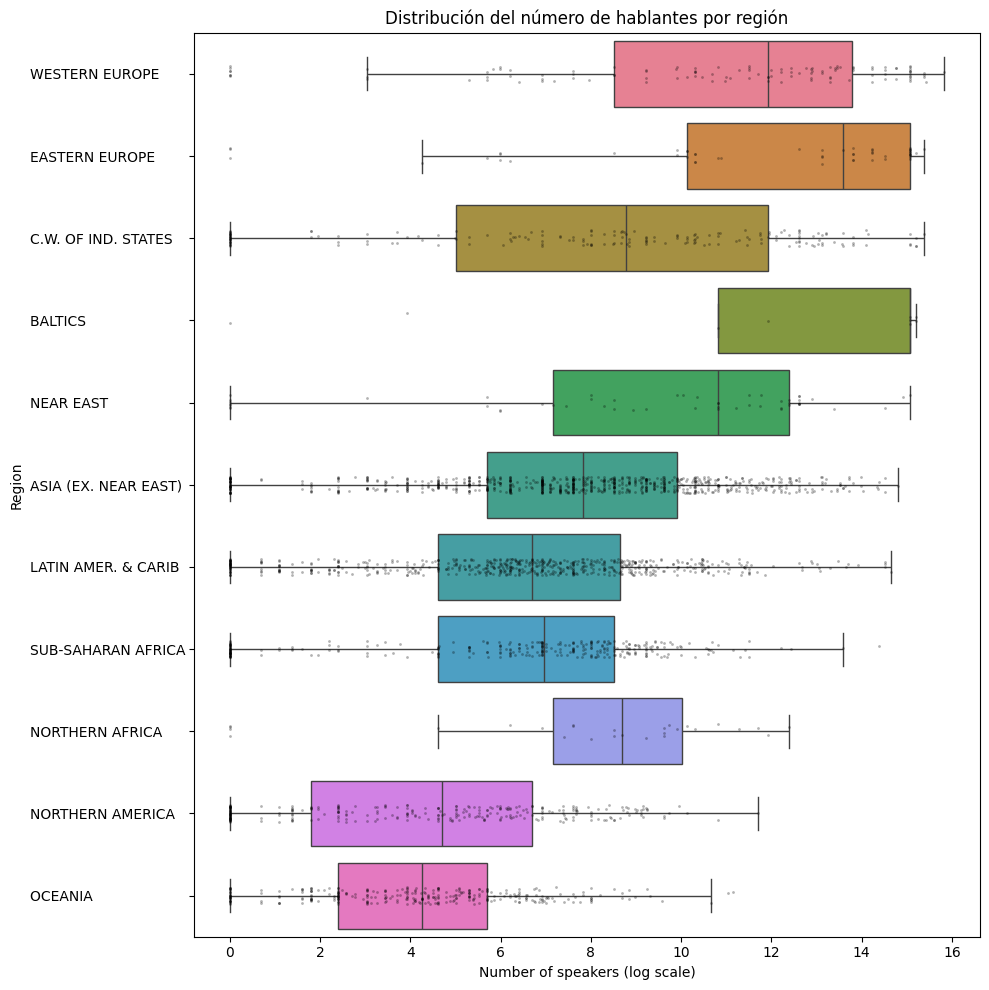

In [7]:
plt.figure(figsize=(10,10))

ax = sns.boxplot(
    x="Log_speakers",
    y="Region",
    hue="Region",
    data=df,
    showfliers=False,
    legend=False
)

sns.stripplot(
    x="Log_speakers",
    y="Region",
    data=df,
    color="black",
    alpha=0.3,
    size=2,
    legend=False
)

ax.set_yticks(ax.get_yticks())

ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0,
    ha="left"
)

ax.tick_params(axis='y', pad=115)

plt.xlabel("Number of speakers (log scale)")
plt.ylabel("Region")

plt.title("Distribución del número de hablantes por región")

plt.tight_layout()
plt.savefig("src/img/H2-boxplot&stripplot.png",
            dpi=300,
            bbox_inches="tight")
plt.show()

#### IQR del número de hablantes por región

In [12]:
iqr_region = df.groupby("Region")["Number_speakers"].agg(
    lambda x: x.quantile(0.75) - x.quantile(0.25)
)

iqr_region.sort_values(ascending=False)

Region
EASTERN EUROPE                         3475000.0
BALTICS                                3450000.0
WESTERN EUROPE                          970000.0
NEAR EAST                               238700.0
C.W. OF IND. STATES                     149850.0
NORTHERN AFRICA                          21181.5
ASIA (EX. NEAR EAST)                     19700.0
LATIN AMER. & CARIB                       5577.0
SUB-SAHARAN AFRICA                        4900.0
NORTHERN AMERICA                           805.0
OCEANIA                                    290.0
Name: Number_speakers, dtype: float64

## H2: Interpretación y resultados

El boxplot en escala logarítmica permite observar la distribución del número de hablantes de las lenguas en peligro según la región geográfica, mientras que el stripplot complementa la representación mostrando la dispersión individual de los registros. De forma general, se aprecia una elevada heterogeneidad entre regiones, existiendo diferencias notables tanto en la mediana como en la amplitud de las distribuciones.

Visualmente, regiones como Asia (excepto Oriente Próximo) presentan una gran dispersión y una elevada concentración de registros distribuidos a lo largo de prácticamente toda la escala, lo que indica la coexistencia de lenguas con muy pocos hablantes junto a otras con comunidades lingüísticas considerablemente mayores. Sin embargo, el cálculo del rango intercuartílico (IQR) muestra que Europa del Este y Europa Occidental presentan una variabilidad aún mayor dentro del 50% central de la distribución.

En concreto, Europa del Este (3.475.000) y Europa Occidental (970.000) obtienen algunos de los valores de IQR más elevados del conjunto analizado, junto con la región de los Bálticos (3.450.000). Esto refleja una diferencia especialmente pronunciada entre lenguas con menor y mayor número de hablantes dentro de dichas regiones. Por el contrario, aunque Asia presenta una gran amplitud total y numerosos valores extremos, su IQR es considerablemente inferior (19.700), indicando que la parte central de la distribución se encuentra más concentrada.

Estos resultados sugieren que la percepción visual de una mayor dispersión en Asia está fuertemente influida por la presencia de valores extremos y por el elevado número de registros presentes en la región. En cambio, el IQR permite analizar específicamente la variabilidad de la zona central de los datos, mostrando que la heterogeneidad interna es mayor en las regiones europeas.

## H2 - Conclusiones

Aunque visualmente Asia presenta una mayor dispersión global en el número de hablantes, debido a la amplitud de la distribución y a la presencia de numerosos valores extremos, el análisis del rango intercuartílico (IQR) muestra que la variabilidad en la zona central de los datos es mayor en las regiones europeas. Esto indica que las diferencias entre lenguas con menor y mayor número de hablantes dentro del 50% central de la distribución son más pronunciadas en Europa que en Asia.

De esta manera, la hipótesis planteada queda solo **parcialmente respaldada**. Si bien Asia concentra lenguas con cantidades de hablantes muy dispares, incluyendo tanto lenguas con miles de hablantes como otras cercanas a la extinción, la variabilidad observada en los valores centrales de la distribución no resulta superior a la de las regiones europeas. Por tanto, los resultados muestran que la elevada dispersión asiática está influida principalmente por la presencia de valores extremos, mientras que en Europa la variabilidad interna del conjunto de datos es más consistente.

# H3: Hablantes y nivel de peligro de desaparición
Hipótesis: **Las lenguas con más hablantes tienen un menor riesgo de desaparecer.**  
Evaluaremos esta hipótesis con el **coeficiente de correlación de Spearman** ya que mide la relación monótona entre dos variables sin exigir normalidad, sin asumir linealidad y funciona con variables ordinales como nuestro endangerment_score. 
*Evaluación de los resultados*:
-	Si al aumentar una variable, la otra tiende a disminuir, ρ será negativo.
-	Si ambas crecen juntas, ρ será positivo.
-	Si no hay patrón monótono, ρ estará cerca de 0.


In [13]:
from scipy.stats import spearmanr

In [14]:
# Filtrar filas válidas
df_corr = df[['Number_speakers', 'endangerment_score']].dropna()

# Calcular Spearman
rho, pval = spearmanr(df_corr['Number_speakers'], df_corr['endangerment_score'])

print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {pval:.3e}")

Spearman rho: -0.699
p-value: 0.000e+00


## H3 - Resultados e interpretación

Resultados e interpretación
Spearman rho: -0.699
p-value: 0.000e+00  
El valor de la correlación de Spearman (-0.699) indica que las lenguas con más hablantes tienden a presentar niveles más bajos de amenaza.  
El p-value asociado muy cercano al 0 confirma que se trata de una erlación estadísticamente significativa, es decir, altamente improbable en el caso de hipótoesis nula de ausencia de asociación.

## H3 - Visualización

Gráfico que muestra la distribución del número de hablantes (number_of_speakers), evidenciando su marcada no normalidad. Esta asimetría justifica que no se asuma una relación lineal entre las variables de la hipótesis y, por lo tanto, justifica el uso del coeficiente de correlación de Spearman.

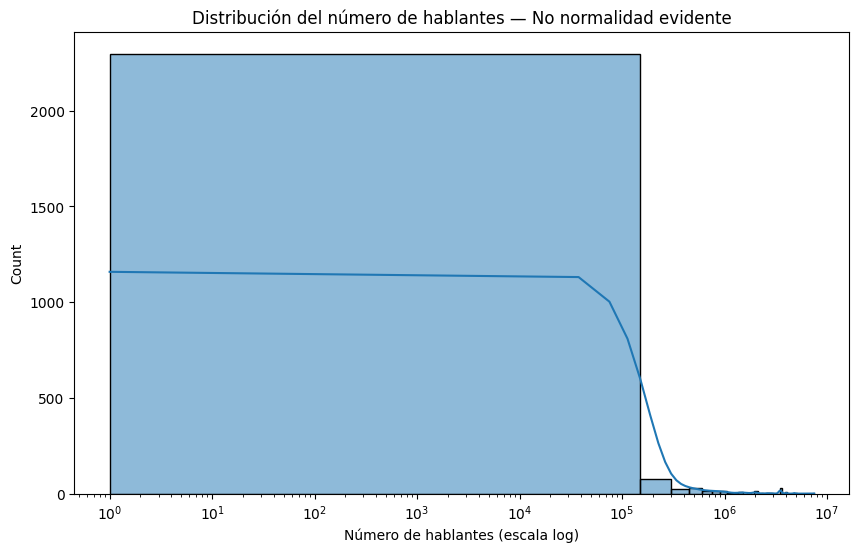

In [15]:
plt.figure(figsize=(10,6))

# Evitar problemas con ceros
speakers = df['Number_speakers']
speakers = speakers[speakers > 0]

sns.histplot(speakers, bins=50, kde=True)
plt.xscale('log')
plt.xlabel("Número de hablantes (escala log)")
plt.title("Distribución del número de hablantes — No normalidad evidente")
plt.savefig("src/img/H3-1.png",
            dpi=300,
             bbox_inches="tight") 
plt.show()

La relación entre número de hablantes y grado de peligro se visualiza de forma clara mediante un scatterplot con escala logarítmica en el eje de hablantes. La nube de puntos muestra una tendencia monótona decreciente, que confirma la correlación negativa observada en el análisis de Spearman.

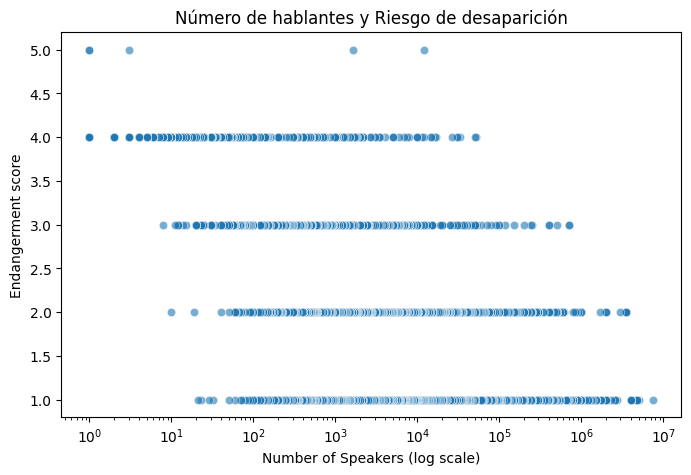

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='Number_speakers',
    y='endangerment_score',
    alpha=0.6
)

plt.xscale('log')
plt.xlabel('Number of Speakers (log scale)')
plt.ylabel('Endangerment score')
plt.title('Número de hablantes y Riesgo de desaparición')

plt.savefig("src/img/H3-2.png",
            dpi=300,
            bbox_inches="tight") 

plt.show()

# H4: Densidad de población y número de lenguas en riesgo de desaparición

Hipótesis: **Los países más densamente poblados no tienen necesariamente más lenguas en peligro.**

La densidad poblacional no correlaciona con el número de lenguas amenazadas por país.  
Para evaluar esta hipótesis usaremos la correlación de Pearson analiza la correlación lineal entre dos variables numéricas. Number of speakers y, recordemos que endangerment degree ha sido cuantificada en la variable numérica endangerment_score.

Antes de calcular el coeficiente de correlación de Pearson vemos que la columna de densidad de población tiene 9 filas sin datos.

- 1 se corresponde al Romaní hablado en Montenegro  
- 4 son lenguas habladas en Costa de Marfil  
- Las cuatro restantes se corresponden con lenguas habladas en los países: Niue, Tokelau, Norfolk Island(Australia), Pitcarin(UK) Asignaremos los datos de densidad de población de Montenegro y Costa de Marfil ya que contamos con valores oficiales

In [17]:
df[df['Pop_density'].isna()== True]

,ID,Name_English,Countries,Degree_endangerment,Number_speakers,Description_location,endangerment_score,Countries_list,Region,Population,...,Arable,Crops,Other,Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Log_speakers
43,405,Romani,"Albania, Germany, Austria, Belarus, Bosnia and...",Definitely endangered,3500000.0,"many European countries, most densely in East-...",2,Montenegro,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.068274
626,703,Niuean,Niue,Definitely endangered,14000.0,"1260 on Niue, remainder mostly in New Zealand",2,Niue,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.546884
946,713,Tokelauan,Tokelau,Severely endangered,4500.0,Tokelau and New Zealand,3,Tokelau,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.412055
1275,15,Jeri,Côte d'Ivoire,Severely endangered,1500.0,NaN,3,Ivory Coast,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.313887
1385,1320,Ega,Côte d'Ivoire,Severely endangered,1000.0,NaN,3,Ivory Coast,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.908755
1574,715,Norfolk-Pitcairn (Norfolk),Norfolk Island (Australia),Definitely endangered,580.0,Norfolk Island,2,Norfolk Island (Australia),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.364751
2169,2622,Norfolk-Pitcairn (Pitcairn),Pitcairn (U.K.),Vulnerable,50.0,Pitcairn Island,1,Pitcairn (U.K.),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.931826
2616,1321,Eotile,Côte d'Ivoire,Extinct,0.0,NaN,5,Ivory Coast,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
2774,16,Tonjon,Côte d'Ivoire,Extinct,0.0,NaN,5,Ivory Coast,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000


In [18]:
df = df.dropna(subset=['Pop_density'])
df.info()

<class 'pandas.DataFrame'>
Index: 2801 entries, 0 to 2809
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    2801 non-null   int64  
 1   Name_English          2801 non-null   str    
 2   Countries             2801 non-null   str    
 3   Degree_endangerment   2801 non-null   str    
 4   Number_speakers       2801 non-null   float64
 5   Description_location  1993 non-null   str    
 6   endangerment_score    2801 non-null   int64  
 7   Countries_list        2801 non-null   str    
 8   Region                2801 non-null   str    
 9   Population            2801 non-null   float64
 10  Area_sq_mi            2801 non-null   float64
 11  Pop_density           2801 non-null   float64
 12  Coastline             2801 non-null   float64
 13  Migration             2801 non-null   float64
 14  Infant_mortality      2801 non-null   float64
 15  GDP                   2801 non-null  

In [19]:
''' 
Reemplazamos los datos por la densidad de población de estos países
Montenegro: 46.0
Costa de Marfil 98.0
'''
df.loc[df['Countries_list'] == "Ivory Coast", 'Pop_density'] = 98.0
df.loc[df['Countries_list'] == "Montenegro", 'Pop_density'] = 46.0

In [20]:
# dataset con númer de lenguas en peligro por país
df_country_counts = df.groupby("Countries_list")["Name_English"].count().reset_index()
df_country_counts.rename(columns={"Name_English": "num_endangered_languages"}, inplace=True)
df_country_counts.head()

,Countries_list,num_endangered_languages
0,Afghanistan,21
1,Albania,3
2,Algeria,10
3,Angola,4
4,Argentina,16


In [21]:
df_final = df.merge(df_country_counts, on="Countries_list", how="left")
df_final.head()

,ID,Name_English,Countries,Degree_endangerment,Number_speakers,Description_location,endangerment_score,Countries_list,Region,Population,...,Crops,Other,Climate,Birthrate,Deathrate,Agriculture,Industry,Service,Log_speakers,num_endangered_languages
0,1022,South Italian,Italy,Vulnerable,7500000.0,"Campania, Lucania (Basilicata), Abruzzi (Abruz...",1,Italy,WESTERN EUROPE,58133509.0,...,9.53,62.68,NaN,8.72,10.40,0.021,0.291,0.688,15.830414,29
1,1023,Sicilian,Italy,Vulnerable,5000000.0,"Sicily (Sicilia), southern and central Calabri...",1,Italy,WESTERN EUROPE,58133509.0,...,9.53,62.68,NaN,8.72,10.40,0.021,0.291,0.688,15.424949,29
2,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Germany,WESTERN EUROPE,82422299.0,...,0.59,65.56,3.0,8.25,10.62,0.009,0.296,0.695,15.384127,8
3,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Denmark,WESTERN EUROPE,5450661.0,...,0.19,45.79,3.0,11.13,10.36,0.018,0.246,0.735,15.384127,1
4,383,Low Saxon,"Germany, Denmark, Netherlands, Poland, Russian...",Vulnerable,4800000.0,"northern Germany, the north-eastern part of th...",1,Netherlands,WESTERN EUROPE,16491461.0,...,0.97,72.32,3.0,10.90,8.68,0.021,0.244,0.736,15.384127,5


In [22]:
from scipy.stats import pearsonr

r, p_value = pearsonr(df_final['Pop_density'], df_final['endangerment_score'])

print("Coeficiente de Pearson:", r)
print("p-valor:", p_value)

Coeficiente de Pearson: -0.05881789288845541
p-valor: 0.001844363943915659


## H4 Resultados e interpretación


**Coeficiente de Pearson:** −0.0587
**p‑valor:** 0.00187  
No hay relación lineal entre la densidad de población y número de lenguas en peligro.  

Aunque el p‑valor asociado (p = 0.0019) es estadísticamente significativo debido al tamaño de la muestra, la magnitud del coeficiente es extremadamente baja, por lo que la relación carece de importancia práctica.  

Estos resultados apoyan la hipótesis planteada: los países más densamente poblados no presentan necesariamente un mayor número de lenguas en peligro.

## H4 - Visualización

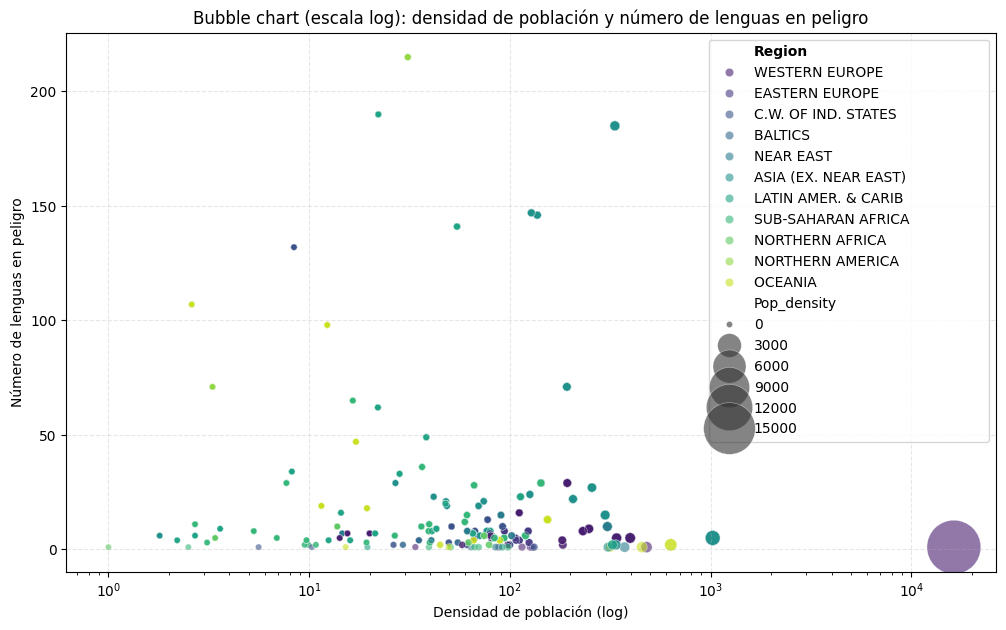

In [23]:
plt.figure(figsize=(12,7))
# el tamaño de las burbujas es en función de la población total y no por la densidad
sns.scatterplot(
    data=df_final,
    x="Pop_density",
    y="num_endangered_languages",
    size="Pop_density",
    sizes=(20, 1500),   
    hue="Region",
    alpha=0.6,
    palette="viridis"
)

# aplicar escala logarítmica en el eje de densidad de población para mejorar la visualización
plt.xscale("log")
plt.title("Bubble chart (escala log): densidad de población y número de lenguas en peligro")
plt.xlabel("Densidad de población (log)")
plt.ylabel("Número de lenguas en peligro")
plt.grid(True, linestyle="--", alpha=0.3)
legend = plt.gca().get_legend()
legend.get_title().set_fontweight('bold')
# Poner en negrita Region y Population dentro de la leyenda
for text in legend.texts:
    if "Region" in text.get_text() or "Population" in text.get_text():
        text.set_fontweight('bold')
        
plt.savefig("src/img/H4.png",
            dpi=300,
            bbox_inches="tight") 

plt.show()

# H5: PIB per cápita y extinción lingüística


Hipótesis: **Los países con mayor PIB per cápita tienen, de media, lenguas con menor grado de peligro: el desarrollo económico se asocia con mayor preservación lingüística.**  
Evaluaremos esta hipótesis con el **coeficiente de correlación de Spearman** ya que mide la relación monótona entre dos variables sin exigir normalidad, sin asumir linealidad y funciona con variables ordinales como nuestro `endangerment_score`. El PIB per cápita también presenta una distribución muy sesgada con outliers extremos, lo que hace que Pearson no sea adecuado.  
*Evaluación de los resultados*:
- Si al aumentar el PIB per cápita el score de peligro tiende a disminuir, ρ será negativo → el desarrollo económico protege las lenguas.
- Si ambas variables crecen juntas, ρ será positivo → el desarrollo económico no frena la extinción.
- Si no hay patrón monótono, ρ estará cerca de 0 → el PIB no explica el grado de peligro.

In [ ]:
# DF con columnas necesarias - nulos
df_h5 = df[['GDP', 'endangerment_score']].dropna()

# Check de que GDP tiene valores numéricos; sustituir las comas x puntos
df_h5['GDP'] = (
    df_h5['GDP']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

print(f"filas válidas para la H5: {len(df_h5)}")
df_h5.describe()

filas válidas para la H3: 2801


,GDP,endangerment_score
count,2801.000000,2801.000000
mean,9934.044984,2.608354
std,11348.916674,1.288045
min,500.000000,1.000000
25%,2500.000000,2.000000
50%,5000.000000,2.000000
75%,9000.000000,4.000000
max,55100.000000,5.000000


In [25]:
from scipy.stats import spearmanr

corr, p_valor = spearmanr(df_h5['GDP'], df_h5['endangerment_score'])

print(f"Coeficiente de Spearman: {corr:.4f}")
print(f"p-valor:                 {p_valor:.4f}")

if p_valor < 0.05:
    direction = "negativa" if corr < 0 else "positiva"
    
    if abs(corr) < 0.1:
        fuerza = "prácticamente inexistente"
    elif abs(corr) < 0.3:
        fuerza = "débil"
    elif abs(corr) < 0.5:
        fuerza = "moderada"
    else:
        fuerza = "fuerte"
    
    print(f"→ Correlación {direction} (podríamos rechazar H0)")
    print(f"→ Fuerza del efecto: {fuerza} (ρ = {corr:.3f})")
else:
    print("→ No hay evidencia suficiente para rechazar H0")

Coeficiente de Spearman: 0.0710
p-valor:                 0.0002
→ Correlación positiva (podríamos rechazar H0)
→ Fuerza del efecto: prácticamente inexistente (ρ = 0.071)


## H5 - Resultados e interpretación
Spearman rho: 0.071 | p-value: 0.0002

El valor de la correlación de Spearman (0.071) indica una relación 
positiva prácticamente inexistente entre el PIB per cápita de un país 
y el nivel de peligro de sus lenguas.

Aunque el p-value (0.0002) confirma que la relación es estadísticamente 
significativa, esto se debe al gran tamaño muestral (n = 2.801): con tantos 
datos, el test detecta hasta las relaciones más pequeñas como significativas. 
El efecto real es despreciable y no permite afirmar que el desarrollo económico 
proteja las lenguas de su extinción. H5 se rechaza.

## H5. Visualización
La relación entre el PIB per cápita y el grado de peligro de las lenguas 
se visualiza mediante un boxplot dividido en cuartiles de PIB. 
Las cajas muestran distribuciones muy similares entre los cuatro grupos, 
lo que confirma visualmente la correlación prácticamente inexistente 
observada en el análisis de Spearman.

In [ ]:
# dividimos la columna GDP en 4 grupos iguales (cuartiles), para facilitar la visualización
# y los etiquetamos con un grupo descriptivo consecuente 
df_h5['gdp_cuartil'] = pd.qcut(                                         # función para los cuartiles
    df_h5['GDP'],                                                       # columna a dividir en cuartiles
    q=4,                                                                # número de grupos
    labels=['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']     # las etiquetas
)

# creación del lienzo para el gráfico 10x5
fig, ax = plt.subplots(figsize=(10, 5))

# boxplot: eje X = cuartil de PIB, eje Y = score de peligro de extinción
sns.boxplot(
    data=df_h5,                                                         # dataframe con los datos
    x='gdp_cuartil',                                                    # grupos en el eje horizontal (X) con los cuartiles
    y='endangerment_score',                                             # valores en el eje vertical (Y) con el score
    hue='gdp_cuartil',
    palette='muted',                                                    # paleta de colores suaves
    dodge=False,
    legend=False,
    ax=ax                                                               # lienzo creado
)

# etiquetas de los ejes y título 
ax.set_xlabel('Cuartil de PIB per cápita')
ax.set_ylabel('Score de peligro (ascendente))')
ax.set_title('H5 · Score de peligro por cuartil de PIB')

plt.tight_layout()                                                      # ajusta márgenes para que no se corten etiquetas
plt.savefig("src/img/H5-1.png",
            dpi=300,
            bbox_inches="tight")                                         # save en src/ img como png
plt.show()                                                              # muestra el gráfico

Como complemento, el scatterplot con la línea de tendencia muestra   
la relación de forma continua. La línea prácticamente plana confirma   
que no existe una tendencia clara entre el PIB per cápita de un país   
y el nivel de peligro de sus lenguas.

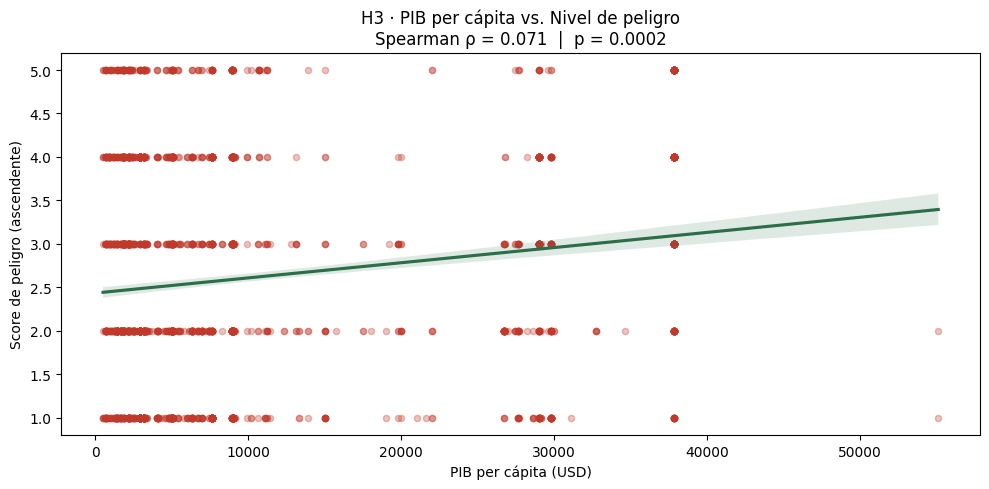

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.regplot(
    data=df_h5,
    x='GDP',
    y='endangerment_score',
    scatter_kws={'alpha': 0.3, 's': 20, 'color': '#c0392b'},
    line_kws={'color': '#2c6e49'},
    ax=ax
)

ax.set_xlabel('PIB per cápita (USD)')
ax.set_ylabel('Score de peligro (ascendente)')
ax.set_title(
    f'H5 · PIB per cápita vs. Nivel de peligro\nSpearman ρ = {corr:.3f}  |  p = {p_valor:.4f}',
    fontsize=12
)

plt.tight_layout()
plt.savefig("src/img/H5-2.png",
            dpi=300,
            bbox_inches="tight")                                         # save en src/ img como png
plt.show()

In [ ]:
from scipy.stats import kruskal, shapiro, f_oneway

# dividimos la columna GDP en 4 grupos iguales (cuartiles), de nuevo
# y los etiquetamos con un grupo descriptivo consecuente 
df_h5['gdp_cuartil'] = pd.qcut(
    df_h5['GDP'],
    q=4,
    labels=['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']
)

grupos = [
    df_h5[df_h5['gdp_cuartil'] == cat]['endangerment_score'].values
    for cat in ['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']
]

# Verificar normalidad en cada grupo **(Shapiro-Wilk)**
print("Test de normalidad por grupo (Shapiro-Wilk):")
for g, nombre in zip(grupos, ['Q1', 'Q2', 'Q3', 'Q4']):
    _, p = shapiro(g[:5000])  # Shapiro solo funciona bien con n < 5000
    print(f"  {nombre}: p = {p:.4f} {'✓ Normal' if p > 0.05 else '✗ No normal → usar Kruskal'}")

# Elegir el test según normalidad
# Con datos reales de hablantes es casi seguro que usarás Kruskal-Wallis
stat, p_anova = kruskal(*grupos)
print(f"\nKruskal-Wallis: H = {stat:.3f}  |  p = {p_anova:.4f}")

if p_anova < 0.05:
    print("→ Diferencias significativas entre cuartiles de PIB → aplicar post-hoc")
else:
    print("→ No hay diferencias significativas entre cuartiles")

Test de normalidad por grupo (Shapiro-Wilk):
  Q1: p = 0.0000 ✗ No normal → usar Kruskal
  Q2: p = 0.0000 ✗ No normal → usar Kruskal
  Q3: p = 0.0000 ✗ No normal → usar Kruskal
  Q4: p = 0.0000 ✗ No normal → usar Kruskal

Kruskal-Wallis: H = 80.384  |  p = 0.0000
→ Diferencias significativas entre cuartiles de PIB → aplicar post-hoc


Post-hoc Dunn (p-valores ajustados con Bonferroni):
               Q1 Bajo  Q2 Medio-bajo  Q3 Medio-alto  Q4 Alto
Q1 Bajo         1.0000          0.000         0.0018   0.0072
Q2 Medio-bajo   0.0000          1.000         0.6790   0.0000
Q3 Medio-alto   0.0018          0.679         1.0000   0.0000
Q4 Alto         0.0072          0.000         0.0000   1.0000


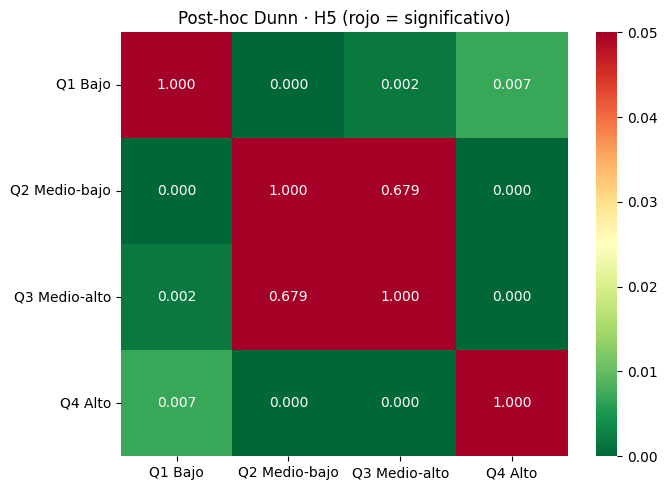

In [ ]:
#pip install scikit-posthocs
from scikit_posthocs import posthoc_dunn

if p_anova < 0.05:
    dunn = posthoc_dunn(
        df_h5,
        val_col='endangerment_score',
        group_col='gdp_cuartil',
        p_adjust='bonferroni'
    )
    print("Post-hoc Dunn (p-valores ajustados con Bonferroni):")
    print(dunn.round(4))

    # Heatmap del post-hoc
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(dunn, annot=True, fmt='.3f', cmap='RdYlGn_r',
                vmin=0, vmax=0.05, ax=ax)
    ax.set_title('Post-hoc Dunn · H5 (rojo = significativo)')
    plt.tight_layout()
    
    plt.savefig("src/img/H5-3.png",
            dpi=300,
            bbox_inches="tight")  
    
    plt.show()

## H5. Conclusiones

El análisis de Spearman muestra una correlación prácticamente inexistente 
(ρ = 0.071) entre el PIB per cápita y el nivel de peligro de las lenguas. 
Sin embargo, el test de Kruskal-Wallis y el post-hoc Dunn revelan que los 
países más pobres (Q1) sí presentan diferencias significativas respecto al 
resto de grupos.

Esto sugiere que el PIB no actúa como un predictor lineal del peligro 
lingüístico, sino que existe un umbral mínimo de desarrollo económico 
por debajo del cual las lenguas están más amenazadas. H5 se rechaza 
en su formulación original.

# H6: Alfabetización y extinción lingüística
Hipótesis: **Los países con mayor tasa de alfabetización tienen, de media, lenguas con menor grado de peligro: la educación puede ayudar a la preservación lingüística.**  
Evaluaremos esta hipótesis con el **t-test de Welch** comparando el `endangerment_score` medio entre dos grupos de países: los que están por encima y por debajo de la mediana de alfabetización. Usamos Welch (y no el t-test clásico) porque no asume varianzas iguales entre grupos, lo que es más seguro con datos reales. Complementaremos con el **tamaño del efecto (Cohen's d)** para no depender únicamente del p-valor.  
*Evaluación de los resultados*:
- Si el grupo de alta alfabetización tiene un score medio significativamente menor, la hipótesis se confirma → la educación actúa como factor protector.
- Si el grupo de baja alfabetización tiene menor score, el resultado sería contrario a lo esperado → la escolarización en lengua oficial podría acelerar el abandono de lenguas locales.
- Si no hay diferencia significativa (p > 0.05), la hipótesis se rechaza → la alfabetización no predice el grado de peligro.

In [ ]:
print(df.columns.tolist())

['ID', 'Name_English', 'Countries', 'Degree_endangerment', 'Number_speakers', 'Description_location', 'endangerment_score', 'Countries_list', 'Region', 'Population', 'Area_sq_mi', 'Pop_density', 'Coastline', 'Migration', 'Infant_mortality', 'GDP', 'Literacy', 'Phones', 'Arable', 'Crops', 'Other', 'Climate', 'Birthrate', 'Deathrate', 'Agriculture', 'Industry', 'Service', 'Log_speakers']


Filas válidas para H4: 2801
Mediana de alfabetización: 89.0%


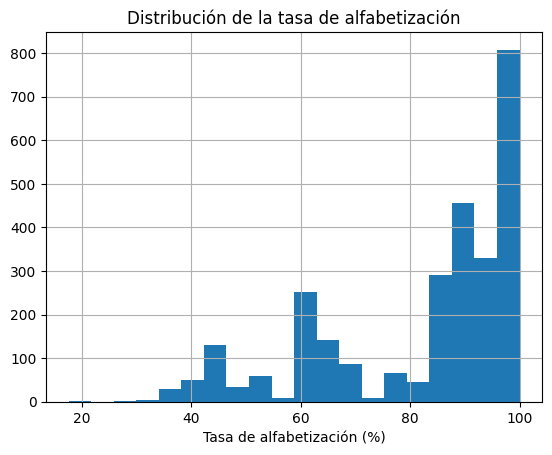

In [ ]:
# DF con columnas necesarias - nulos
df_h6 = df[['Literacy', 'endangerment_score']].dropna()

# Check numérico y conversor de decimales (, y .)
df_h6['Literacy'] = (
    df_h6['Literacy']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

print(f"Filas válidas para H6: {len(df_h6)}")
print(f"Mediana de alfabetización: {df_h6['Literacy'].median():.1f}%")
df_h6['Literacy'].hist(bins=20)
plt.xlabel('Tasa de alfabetización (%)')
plt.title('Distribución de la tasa de alfabetización')

plt.savefig("src/img/H6-1.png",
            dpi=300,
            bbox_inches="tight") 

plt.show()

In [ ]:
from scipy.stats import spearmanr

df_h6 = df[['Literacy', 'endangerment_score']].dropna()

df_h6['Literacy'] = (
    df_h6['Literacy']
    .astype(str)
    .str.replace(',', '.')
    .astype(float)
)

corr_h6, p_valor_h6 = spearmanr(df_h6['Literacy'], df_h6['endangerment_score'])

print(f"Coeficiente de Spearman: {corr_h6:.4f}")
print(f"p-valor:                 {p_valor_h6:.4f}")

if p_valor_h6 < 0.05:
    direction = "negativa" if corr_h6 < 0 else "positiva"
    
    if abs(corr) < 0.1:
        fuerza = "prácticamente inexistente"
    elif abs(corr) < 0.3:
        fuerza = "débil"
    elif abs(corr) < 0.5:
        fuerza = "moderada"
    else:
        fuerza = "fuerte"
    
    print(f"→ Correlación {direction} (podríamos rechazar H0)")
    print(f"→ Fuerza del efecto: {fuerza} (ρ = {corr:.3f})")
else:
    print("→ No hay evidencia suficiente para rechazar H0")

Coeficiente de Spearman: 0.0707
p-valor:                 0.0002
→ Correlación positiva (podríamos rechazar H0)
→ Fuerza del efecto: prácticamente inexistente (ρ = 0.071)


## H6 -Visualización

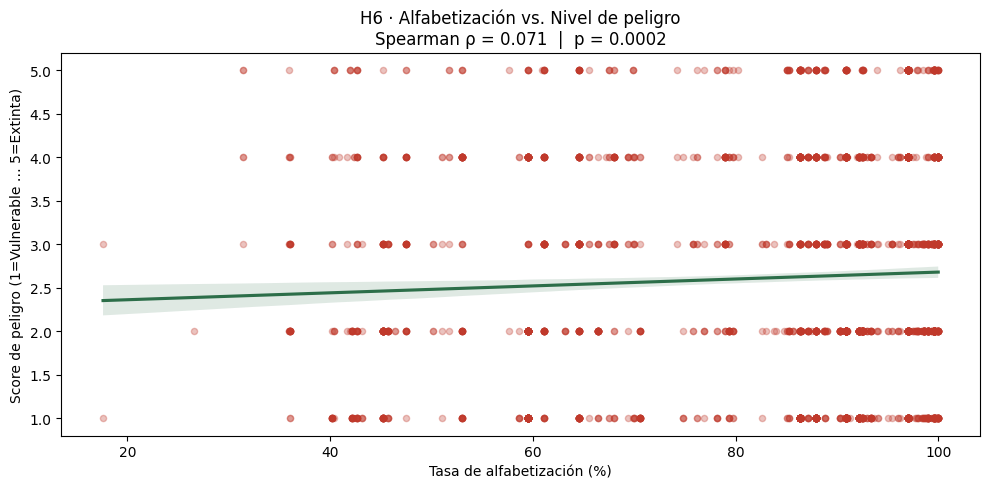

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.regplot(
    data=df_h6,
    x='Literacy',
    y='endangerment_score',
    scatter_kws={'alpha': 0.3, 's': 20, 'color': '#c0392b'},
    line_kws={'color': '#2c6e49'},
    ax=ax
)

ax.set_xlabel('Tasa de alfabetización (%)')
ax.set_ylabel('Score de peligro (1=Vulnerable … 5=Extinta)')
ax.set_title(
    f'H6 · Alfabetización vs. Nivel de peligro\nSpearman ρ = {corr_h6:.3f}  |  p = {p_valor_h6:.4f}',
    fontsize=12
)

plt.tight_layout()
plt.savefig("src/img/H6-2.png",
            dpi=300,
            bbox_inches="tight") 
plt.show()

In [ ]:
from scipy.stats import kruskal, shapiro

# Dividir literacy en 4 cuartiles
df_h6['literacy_cuartil'] = pd.qcut(
    df_h6['Literacy'],
    q=4,
    labels=['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']
)

grupos = [
    df_h6[df_h6['literacy_cuartil'] == cat]['endangerment_score'].values
    for cat in ['Q1 Bajo', 'Q2 Medio-bajo', 'Q3 Medio-alto', 'Q4 Alto']
]

# Normalidad
print("Test de normalidad por grupo (Shapiro-Wilk):")
for g, nombre in zip(grupos, ['Q1', 'Q2', 'Q3', 'Q4']):
    _, p = shapiro(g[:5000])
    print(f"  {nombre}: p = {p:.4f} {'✓ Normal' if p > 0.05 else '✗ No normal → usar Kruskal'}")

# Kruskal-Wallis
stat, p_kruskal = kruskal(*grupos)
print(f"\nKruskal-Wallis: H = {stat:.3f}  |  p = {p_kruskal:.4f}")

if p_kruskal < 0.05:
    print("→ Diferencias significativas entre cuartiles de alfabetización → aplicar post-hoc")
else:
    print("→ No hay diferencias significativas entre cuartiles")

Test de normalidad por grupo (Shapiro-Wilk):
  Q1: p = 0.0000 ✗ No normal → usar Kruskal
  Q2: p = 0.0000 ✗ No normal → usar Kruskal
  Q3: p = 0.0000 ✗ No normal → usar Kruskal
  Q4: p = 0.0000 ✗ No normal → usar Kruskal

Kruskal-Wallis: H = 9.247  |  p = 0.0262
→ Diferencias significativas entre cuartiles de alfabetización → aplicar post-hoc


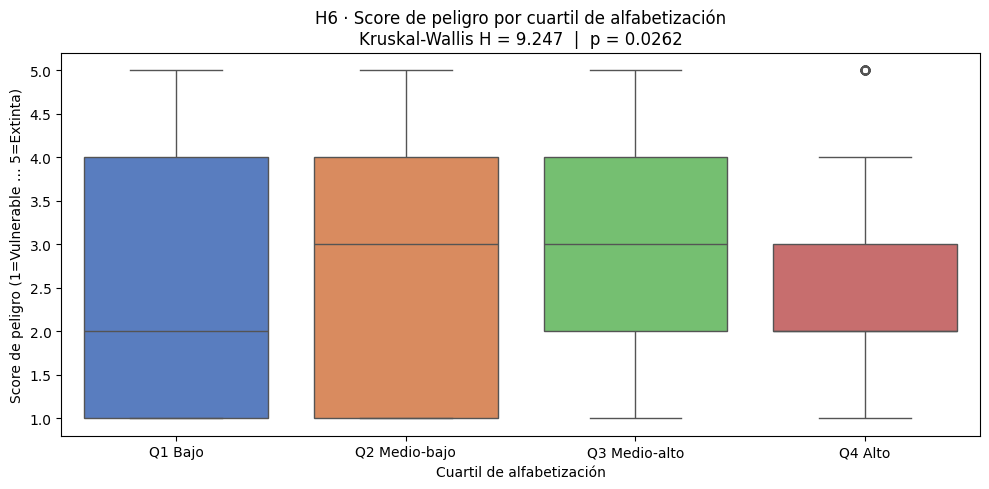

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(
    data=df_h6,
    x='literacy_cuartil',
    y='endangerment_score',
    hue='literacy_cuartil',
    palette='muted',
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_xlabel('Cuartil de alfabetización')
ax.set_ylabel('Score de peligro (1=Vulnerable … 5=Extinta)')
ax.set_title(
    f'H6 · Score de peligro por cuartil de alfabetización\nKruskal-Wallis H = {stat:.3f}  |  p = {p_kruskal:.4f}',
    fontsize=12
)

plt.tight_layout()
plt.savefig("src/img/H6-3.png",
            dpi=300,
            bbox_inches="tight") 
plt.show()

Post-hoc Dunn (p-valores ajustados con Bonferroni):
               Q1 Bajo  Q2 Medio-bajo  Q3 Medio-alto  Q4 Alto
Q1 Bajo         1.0000         0.4537         0.0145   0.7434
Q2 Medio-bajo   0.4537         1.0000         1.0000   1.0000
Q3 Medio-alto   0.0145         1.0000         1.0000   1.0000
Q4 Alto         0.7434         1.0000         1.0000   1.0000


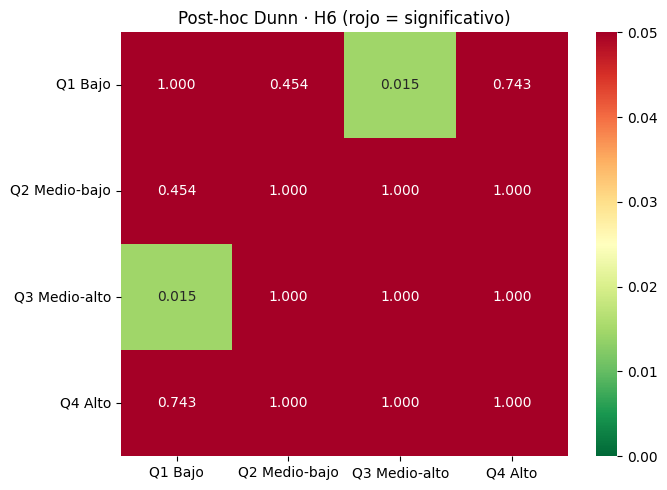

In [ ]:
from scikit_posthocs import posthoc_dunn

if p_kruskal < 0.05:
    dunn = posthoc_dunn(
        df_h6,
        val_col='endangerment_score',
        group_col='literacy_cuartil',
        p_adjust='bonferroni'
    )
    print("Post-hoc Dunn (p-valores ajustados con Bonferroni):")
    print(dunn.round(4))

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(dunn, annot=True, fmt='.3f', cmap='RdYlGn_r',
                vmin=0, vmax=0.05, ax=ax)
    ax.set_title('Post-hoc Dunn · H6 (rojo = significativo)')
    plt.tight_layout()
    plt.savefig("src/img/H6-4.png",
            dpi=300,
            bbox_inches="tight")  
    plt.show()

## H6 - Conclusiones

El análisis de Spearman muestra una correlación prácticamente inexistente
(ρ = 0.071) entre la tasa de alfabetización y el nivel de peligro de las
lenguas. El post-hoc Dunn únicamente detecta diferencias significativas
entre Q1 (baja alfabetización) y Q3 (media-alta alfabetización), sin que
exista una tendencia progresiva clara entre los cuatro grupos.

La alfabetización por sí sola no predice de forma consistente el grado
de peligro de las lenguas. H6 se rechaza.